In [2]:
import torch

# GPU 사용 가능 여부 확인
print(f"GPU 사용 가능 여부: {torch.cuda.is_available()}")

# 사용 가능한 GPU 개수 및 이름 확인
if torch.cuda.is_available():
    print(f"GPU 개수: {torch.cuda.device_count()}")
    print(f"현재 GPU 이름: {torch.cuda.get_device_name(0)}")

GPU 사용 가능 여부: True
GPU 개수: 4
현재 GPU 이름: NVIDIA TITAN Xp


In [3]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"  # 사용할 GPU 번호 입력
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
import glob 
import os # 파일/폴덛 경로 존재 여부 확인 라이브러리 

# 경로 지정 
root='./'
image_folder_path = os.path.join(root, 'food_images') # 데이터셋을 저장할 폴더 경로 생성 ./food_images

# images 폴더가 없으면 생성(이미 존재하면 건너뜀)
if not os.path.exists(image_folder_path):
    os.makedirs(image_folder_path)

import kaggle
kaggle.api.dataset_download_files('trolukovich/food11-image-dataset', path=image_folder_path, unzip=True)

print(image_folder_path)
print(glob.glob(image_folder_path+'/*')) # food_images 포더 안의 모든 파일/폴더 목록 출력


Dataset URL: https://www.kaggle.com/datasets/trolukovich/food11-image-dataset
./food_images
['./food_images/training', './food_images/evaluation', './food_images/validation']


In [ ]:
import numpy as np
import torch 
from torch.utils.data import Dataset
from torchvision import datasets, transforms

# train 용 transform - data augmentation + normalize 적용 
train_transform = transforms.Compose([
    transforms.Resize((300, 300)), # 이미지 크기를 300x300으로 통일
    transforms.RandomHorizontalFlip(), # 50% 확률로 이미지 좌우 반전(데이터 증강)
    transforms.RandomRotation(10), # -10~+10도 랜덤 회전(데이터 증강)
    transforms.ToTensor(), # PIL 이미지 -> Tensor 변환(0~255 -> 0~1)
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# validation/test용 transform - augmentation없이 normalize만 적용 
# 실제 성능 평가이므로 원본 이미지 그대로 사용
val_test_transform = transforms.Compose([
    transforms.Resize((300, 300)), # 이미지 크기를 300x300으로 통일
    transforms.ToTensor(), # PIL 이미지 -> Tensor 변환
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Food-11 데이터셋은 이미 training/validation/evaluation 폴더로 분리되어 있음
# random_split없이 각 폴더를 직접 ImageFolder로 로드
train_dataset = datasets.ImageFolder(root=image_folder_path + '/training',  transform=train_transform)
val_dataset   = datasets.ImageFolder(root=image_folder_path + '/validation', transform=val_test_transform)
test_dataset  = datasets.ImageFolder(root=image_folder_path + '/evaluation', transform=val_test_transform)


print(f"Train data 개수: {len(train_dataset)}") # 9866장
print(f"Validation data 개수: {len(val_dataset)}") # 3430장
print(f"Test data 개수: {len(test_dataset)}") # 3347장

print(train_dataset.class_to_idx) # 클래스 이름과 인덱스 매핑 출력

Train data 개수: 9866
Validation data 개수: 3430
Test data 개수: 3347
{'Bread': 0, 'Dairy product': 1, 'Dessert': 2, 'Egg': 3, 'Fried food': 4, 'Meat': 5, 'Noodles-Pasta': 6, 'Rice': 7, 'Seafood': 8, 'Soup': 9, 'Vegetable-Fruit': 10}


In [6]:
batch_size=32

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True,  num_workers=8)
val_loader   = torch.utils.data.DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, num_workers=8)
test_loader  = torch.utils.data.DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, num_workers=8)

# 1개 batch 추출
images, labels = next(iter(train_loader))

# images, labels에 각각 32개의 batch가 로드 
# images는 300x300 사이즈 RGB 이미지 32장이 1개 batch로 구성
print(images.shape)
print(labels.shape)

torch.Size([32, 3, 300, 300])
torch.Size([32])


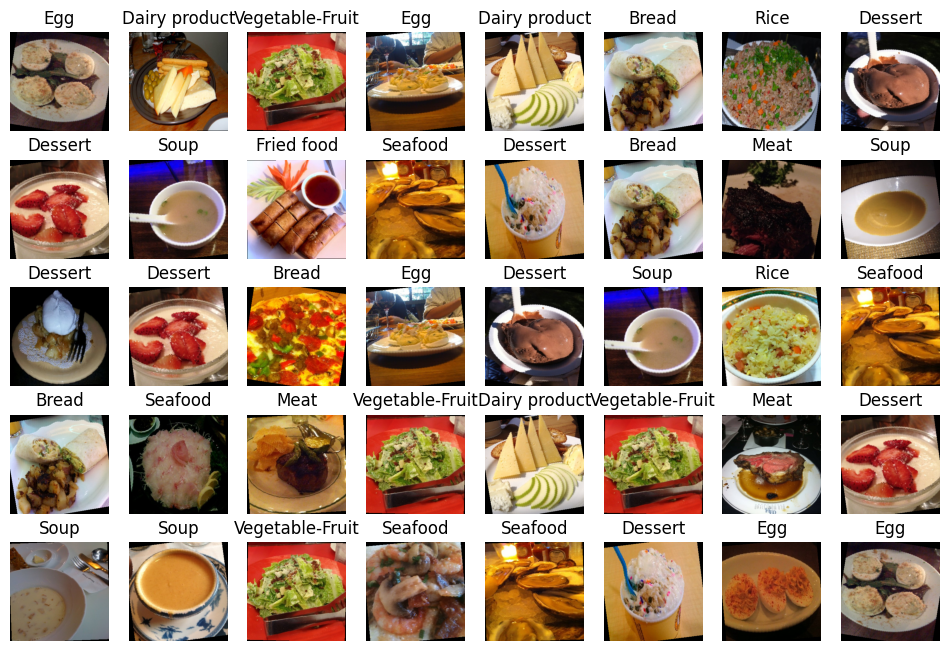

In [7]:
import matplotlib.pyplot as plt

# ImageFolder의 속성 값인 class_to_idx를 할당 
labels_map = {v:k for k,v in train_dataset.class_to_idx.items()}

figure=plt.figure(figsize=(12,8))
cols, rows = 8,5

for i in range(1, cols*rows +1):
    sample_idx = torch.randint(len(images), size=(1,)).item()
    img, label = images[sample_idx], labels[sample_idx].item()
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis("off")
    img = img * 0.5 + 0.5
    plt.imshow(torch.permute(img, (1,2,0)))
plt.show()

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3,  out_channels=32,  kernel_size=3, padding=1, stride=1)
        self.bn1   = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64,  kernel_size=3, padding=1, stride=1)
        self.bn2   = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1, stride=1)
        self.bn3   = nn.BatchNorm2d(128)
        self.pool  = nn.AdaptiveAvgPool2d((4, 4))  
        self.dropout = nn.Dropout(p=0.5)
        self.fc1 = nn.Linear(128*4*4, 512)  
        self.fc2 = nn.Linear(512, 11)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.max_pool2d(x, kernel_size=2, stride=2)
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.max_pool2d(x, kernel_size=2, stride=2)
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.pool(x)           
        x = x.view(-1, 128*4*4)   
        x = self.dropout(x)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

cnn = CNN().to(device)

loss of 0 epoch, 0 index : 1.3446624279022217
loss of 0 epoch, 100 index : 1.1913560628890991
loss of 0 epoch, 200 index : 1.1368027925491333
loss of 0 epoch, 300 index : 1.3937379121780396
Epoch 0 | Val Loss: 1.1897 | Val Acc : 2045/3430 (59.6%)
  → Val Loss 개선! 모델 저장 (best_val_loss: 1.1897)
loss of 1 epoch, 0 index : 1.519171953201294
loss of 1 epoch, 100 index : 1.336464524269104
loss of 1 epoch, 200 index : 1.3436022996902466
loss of 1 epoch, 300 index : 1.3984190225601196
Epoch 1 | Val Loss: 1.1197 | Val Acc : 2123/3430 (61.9%)
  → Val Loss 개선! 모델 저장 (best_val_loss: 1.1197)
loss of 2 epoch, 0 index : 1.000712275505066
loss of 2 epoch, 100 index : 1.1471271514892578
loss of 2 epoch, 200 index : 1.472116470336914
loss of 2 epoch, 300 index : 1.041252851486206
Epoch 2 | Val Loss: 1.1760 | Val Acc : 2062/3430 (60.1%)
  → 개선 없음 (1/10)
loss of 3 epoch, 0 index : 0.9089968204498291
loss of 3 epoch, 100 index : 1.017146110534668
loss of 3 epoch, 200 index : 1.2360426187515259
loss of 3 ep

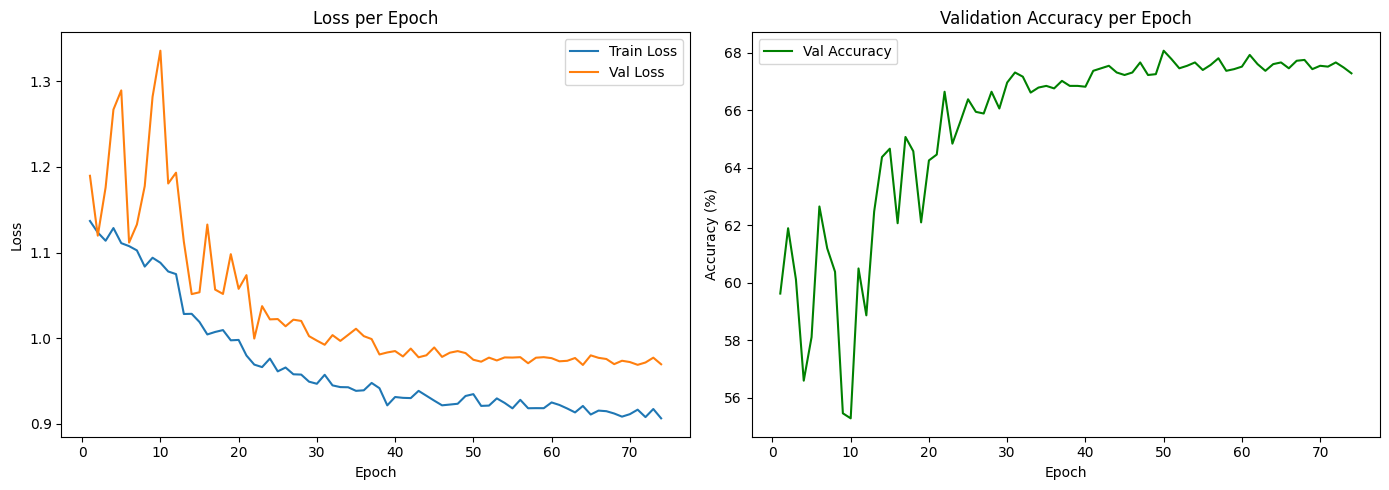

In [18]:
import matplotlib.pyplot as plt

# Parameters
criterion = torch.nn.CrossEntropyLoss()
optimizer = optim.SGD(cnn.parameters(), lr=0.01)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)


# 기록용 리스트
train_losses = []
val_losses   = []
val_accs     = []

# Early Stopping 설정
patience      = 10 # 몇 epoch 동안 개선 없으면 멈출지
best_val_loss = float('inf')
counter       = 0

for epoch in range(300):
    # Train
    cnn.train()
    train_loss=0
    for index, (data,target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = cnn(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

        if index%100==0:
            print("loss of {} epoch, {} index : {}".format(epoch, index, loss.item()))

    train_losses.append(train_loss / len(train_loader))

    # Validation 
    cnn.eval()
    val_loss = 0
    val_correct =0
    with torch.no_grad():
        for data, target in val_loader:
            data, target = data.to(device), target.to(device)
            output = cnn(data)
            val_loss += criterion(output, target).item()
            pred = output.argmax(dim=1, keepdim=True)
            val_correct += pred.eq(target.view_as(pred)).sum().item()
    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)     # epoch 평균 loss 저장
    val_accs.append(100. * val_correct / len(val_loader.dataset))    

    # validation 루프 끝나고 추가
    scheduler.step(avg_val_loss)  # val loss 기반으로 lr 자동 조정
    
    print("Epoch {} | Val Loss: {:.4f} | Val Acc : {}/{} ({:.1f}%)".format(epoch, val_loss/len(val_loader), 
                                                                           val_correct, len(val_loader.dataset), 100. *val_correct/len(val_loader.dataset)))

    # Early Stopping 체크
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        counter = 0
        torch.save(cnn.state_dict(), 'best_model.pth')  # 가장 좋은 모델 저장
        print(f"  → Val Loss 개선! 모델 저장 (best_val_loss: {best_val_loss:.4f})")
    else:
        counter += 1
        print(f"  → 개선 없음 ({counter}/{patience})")
        if counter >= patience:
            print(f"\nEarly Stopping! {epoch+1} epoch에서 조기 종료")
            break
    
epochs = range(1, len(train_losses) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss 그래프
ax1.plot(epochs, train_losses, label='Train Loss')
ax1.plot(epochs, val_losses,   label='Val Loss')
ax1.set_title('Loss per Epoch')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

# Accuracy 그래프
ax2.plot(epochs, val_accs, label='Val Accuracy', color='green')
ax2.set_title('Validation Accuracy per Epoch')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()

plt.tight_layout()
plt.show()

In [19]:
cnn.eval()
test_loss = 0
correct=0

with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = cnn(data)
        test_loss += criterion(output, target).item()
        pred = output.argmax(dim=1, keepdim=True)
        correct += pred.eq(target.view_as(pred)).sum().item()

print("\nTest set : Average loss: {:.4f}, Accuracy : {}/{} ({:.0f}%)\n".format(
    test_loss/len(test_loader), correct, len(test_loader.dataset), 100. * correct/len(test_loader.dataset)
))


Test set : Average loss: 0.9234, Accuracy : 2281/3347 (68%)



/tmp/ipykernel_1788684/3641446029.py:26: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1788684/3641446029.py:26: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1788684/3641446029.py:26: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1788684/3641446029.py:26: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/undergraduate/miniconda3/envs/urop_pet/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/undergraduate/miniconda3/envs/urop_pet/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaV

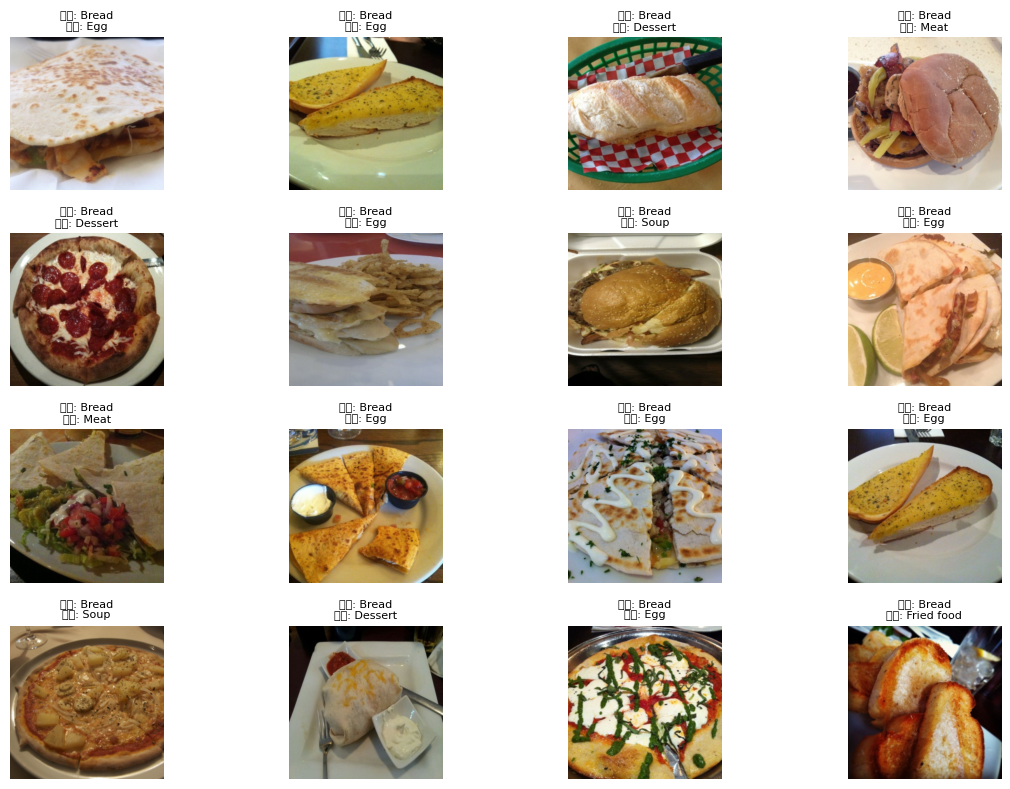

In [21]:
wrong_imgs   = []
wrong_preds  = []
wrong_labels = []

cnn.eval()
with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = cnn(data)
        pred = output.argmax(dim=1)
        
        # 틀린 것만 저장
        wrong_mask = pred != target
        wrong_imgs.extend(data[wrong_mask].cpu())
        wrong_preds.extend(pred[wrong_mask].cpu())
        wrong_labels.extend(target[wrong_mask].cpu())

# 틀린 이미지 16장 시각화
figure = plt.figure(figsize=(12, 8))
for i in range(min(16, len(wrong_imgs))):
    ax = figure.add_subplot(4, 4, i+1)
    img = wrong_imgs[i] * 0.5 + 0.5  # Normalize 역변환
    plt.imshow(torch.permute(img, (1, 2, 0)))
    plt.title(f'실제: {train_dataset.classes[wrong_labels[i]]}\n예측: {train_dataset.classes[wrong_preds[i]]}', fontsize=8)
    plt.axis('off')
plt.tight_layout()
plt.show()